<a href="https://colab.research.google.com/github/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/blob/main/notebooks/02_Baseline_Model_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression Baseline Model**

## Purpose

This notebook evaluates a multiple linear regression model for predicting airfoil sound pressure level.

Exploratory analysis showed that no specific variable had a strong linear correlation with sound pressure level. However, the combined influence of the five input variables may provide greater predictive information.

Linear regression is therefore used as a simple and interpretable baseline model. Its performance will later be compared with nonlinear regression methods.

# **Import Libraries and Load Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# Define descriptive column names because the original .dat file has no header row
column_names = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level"
]

# Load dataset directly from GitHub repository
data_url = "https://raw.githubusercontent.com/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/refs/heads/main/data/airfoil_self_noise.dat"

df = pd.read_csv(
    data_url,
    sep="\t",
    names=column_names
)

df.head()

,frequency,angle_of_attack,chord_length,free_stream_velocity,displacement_thickness,sound_pressure_level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


# **Multiple Linear Regression Model Development**

## Model Inputs and Output

The regression model uses frequency, angle of attack, chord length, free stream velocity and displacement thickness as input variables. The output variable is the measured sound pressure level.

In [7]:
# Separate the five input variables from the prediction target
X = df[
    [
        "frequency",
        "angle_of_attack",
        "chord_length",
        "free_stream_velocity",
        "displacement_thickness"
    ]
]

y = df["sound_pressure_level"]


## Training and Test Data

The dataset is divided into training and test subsets using an 80/20 split. The model is fitted using only the training data, while the withheld test data is used to evaluate its ability to predict observations not used during model fitting.

**A fixed random state is used so that the data split is reproducible.**

In [8]:
# Reserve 20% of observations for independent model evaluation
# random_state ensures the same split is reproduced each time

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1202
Testing observations: 301


# **Building Model**

In [15]:
# Fit the baseline multiple linear regression model using training data only
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Generate predictions for both training and unseen test observations
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# **Evaluating Model**

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE), and the coefficient of determination (R²).

- **MAE** represents the average absolute difference between measured and predicted sound pressure levels.
- **RMSE** measures prediction error while giving greater weight to larger errors.
- **R²** represents the proportion of variation in sound pressure level explained by the model.

Lower MAE and RMSE values indicate better predictive accuracy, while an R² value closer to 1 indicates that a greater proportion of the variation in the measured output is explained by the model.

In [10]:
# Calculate performance metrics for both datasets to assess model fit
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

results = pd.DataFrame({
    "Metric": ["MAE (dB)", "RMSE (dB)", "R²"],
    "Training": [train_mae, train_rmse, train_r2],
    "Testing": [test_mae, test_rmse, test_r2]
})

results

,Metric,Training,Testing
0,MAE (dB),3.753727,3.672415
1,RMSE (dB),4.826601,4.704109
2,R²,0.503448,0.558298


### Performance Results

The linear regression model achieved a test MAE of approximately 3.67 dB and a test RMSE of approximately 4.70 dB. This indicates that prediction errors are typically several decibels in magnitude, with the larger RMSE showing the influence of larger prediction errors.

The test R² value of approximately 0.56 indicates that the linear model explains about 56% of the variation in sound pressure level within the withheld test data.

Training and testing performance are relatively similar, with no substantial increase in error on the test data. This suggests that there is no obvious large generalisation gap for the linear regression model. However, substantial variation in sound pressure level remains unexplained, providing motivation to
investigate nonlinear regression methods.

## Measured vs Predicted Values

Measured sound pressure levels are compared with model predictions on the withheld test data. The dashed diagonal line represents perfect agreement, where predicted and measured values are equal. Predictions closer to this line indicate smaller prediction errors.

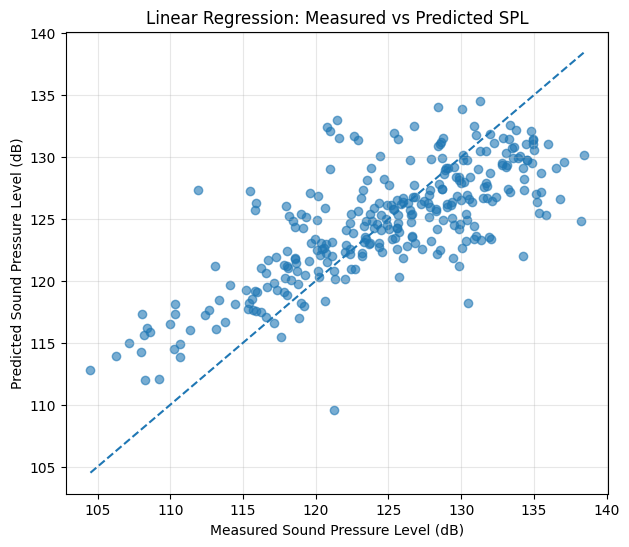

In [13]:
# Comparing Measured vs Predicted Sound Pressure Level
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Measured Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Linear Regression: Measured vs Predicted SPL")
plt.grid(alpha=0.3)

plt.show()

## Residual Analysis

Residuals are calculated as the difference between the measured and predicted
sound pressure levels. An effective regression model should ideally produce
residuals distributed around zero without a strong systematic pattern.

Residual analysis is used to identify prediction bias or structure in the
errors that may not be apparent from the overall performance metrics.

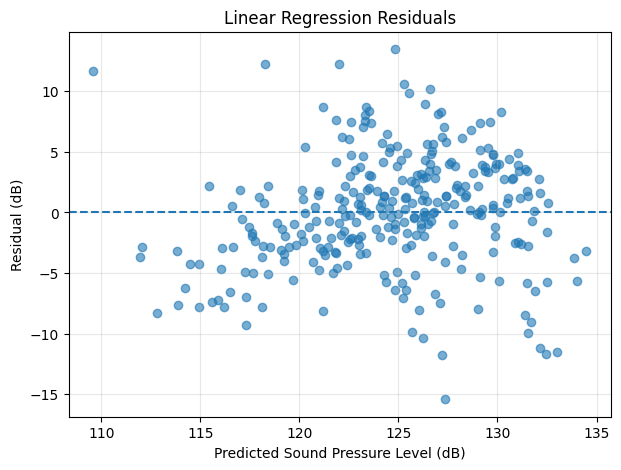

In [12]:
# Residual Analysis
residuals = y_test - y_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_test_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sound Pressure Level (dB)")
plt.ylabel("Residual (dB)")
plt.title("Linear Regression Residuals")
plt.grid(alpha=0.3)

plt.show()

### Residual Observations

The residuals are distributed around zero, indicating no obvious overall prediction bias. However, the residuals show noticeable spread across the predicted sound pressure levels, with some relatively large positive and negative errors.

This indicates that although the linear regression model captures part of the relationship between the input variables and sound pressure level, it does not fully represent the variation present in the experimental data.

# **Findings**

Multiple linear regression provided a simple and interpretable baseline for predicting airfoil sound pressure level from the five available input variables.

The model achieved a test MAE of approximately 3.67 dB, RMSE of 4.70 dB and R² of 0.56. Training and testing performance were relatively similar, indicating no obvious large generalisation gap.

However, the model explains only part of the variation in measured sound pressure level, and prediction errors remain present across the test data. These results establish a baseline against which nonlinear regression methods can be evaluated.

The next stage of the project will investigate whether nonlinear models can capture relationships between the engineering inputs and sound pressure level that are not represented by the linear regression model.